In [4]:
# Install required libraries
!pip install nltk wordcloud gensim gradio -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re, os, pickle, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print(" All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.5 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries imported!
TensorFlow version: 2.20.0


In [1]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load dataset From Drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AIML/DATA/hatevsoffensive_language.csv')
print(df.shape)
print(f"\n Columns: {df.columns.tolist()}")
print(f"\n Class Distribution:")
print(df['label'].value_counts())
print(f"\n Missing Values:")
print(df.isnull().sum())
print(f"\nSample data:")
df.head()

(24783, 2)

 Columns: ['label', 'text']

 Class Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

 Missing Values:
label    0
text     0
dtype: int64

Sample data:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
# Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Contractions dictionary
contractions = {
    "don't":"do not", "can't":"cannot", "won't":"will not",
    "i'm":"i am", "it's":"it is", "that's":"that is",
    "i've":"i have", "i'll":"i will", "i'd":"i would",
    "you're":"you are", "they're":"they are", "we're":"we are",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "hasn't":"has not", "haven't":"have not",
    "didn't":"did not", "doesn't":"does not", "couldn't":"could not",
    "wouldn't":"would not", "shouldn't":"should not"
}

def expand_contractions(text):
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)               # remove numbers
    text = re.sub(r'[^a-z\s]', '', text)          # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']
df = df.dropna(subset=['clean_text', 'label'])

print(f" Cleaned dataset: {df.shape[0]} rows")
print("\nBefore vs After cleaning:")
for i in range(3):
    print(f"\n  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")

✅ Cleaned dataset: 24764 rows

Before vs After cleaning:

  Original : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
  Cleaned  : rt woman complain cleaning house amp man always take trash

  Original : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned  : rt boy dat coldtyga dwn bad cuffin dat hoe st place

  Original : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
  Cleaned  : rt dawg rt ever fuck bitch start cry confused shit


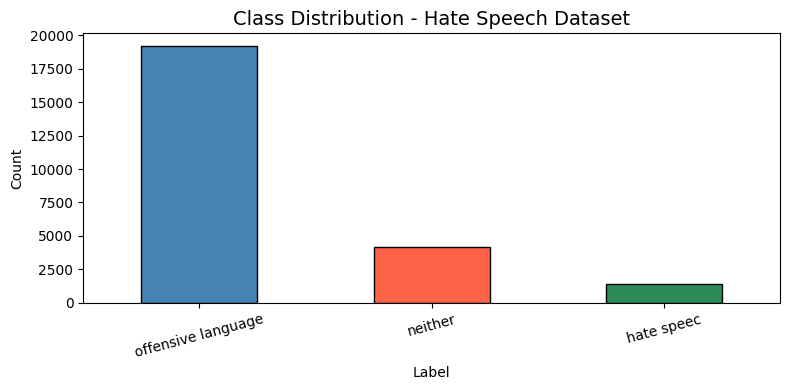

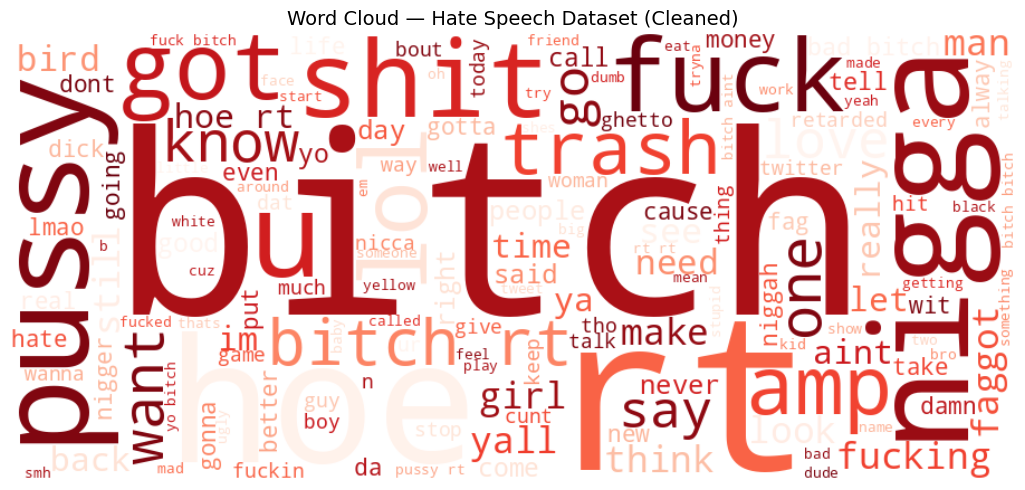

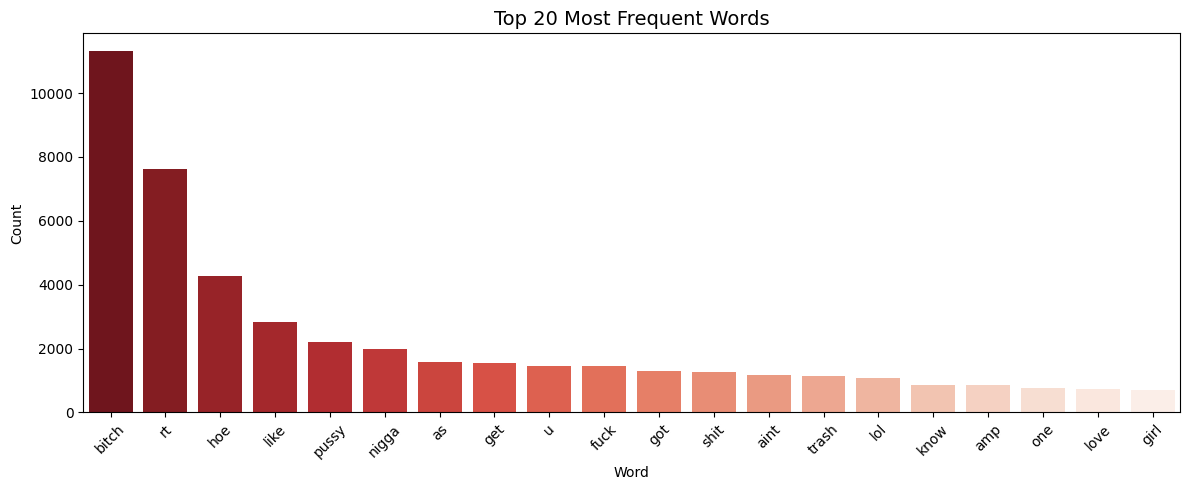

In [8]:
#visualization
# 1. Class Distribution Bar Chart
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar',
    color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
plt.title('Class Distribution - Hate Speech Dataset', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2. WordCloud
all_text = ' '.join(df['clean_text'].tolist())
wc = WordCloud(width=900, height=400,
               background_color='white',
               colormap='Reds',
               max_words=150).generate(all_text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Hate Speech Dataset (Cleaned)', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Top 20 Most Frequent Words
word_freq = Counter(' '.join(df['clean_text']).split())
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])
plt.figure(figsize=(12, 5))
sns.barplot(data=top_words, x='Word', y='Count', palette='Reds_r')
plt.title('Top 20 Most Frequent Words', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Classes     : ['hate speec' 'neither' 'offensive language']
 Encoded as  : [0, 1, 2]
 Num classes : 3

 Train size : 19811
 Test size  : 4953

 Vocabulary size: 16111
 Max sequence length (95th %ile): 15


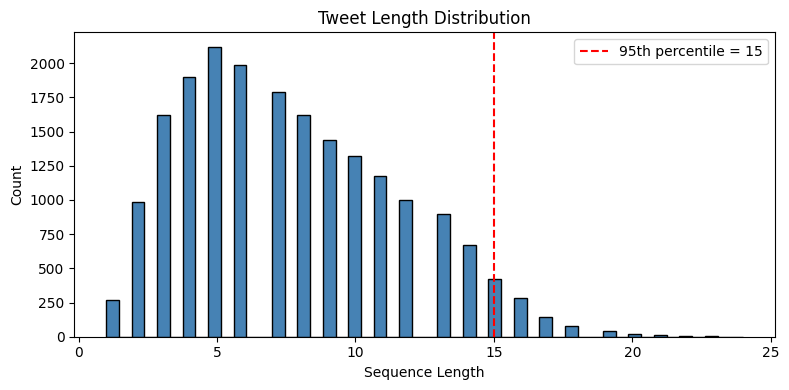


 X_train_pad shape: (19811, 15)
 X_test_pad  shape: (4953, 15)
 y_train_cat shape: (19811, 3)


In [10]:
#Tokenization & Padding
# Encode Labels
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
num_classes = df['encoded_label'].nunique()

print(f" Classes     : {le.classes_}")
print(f" Encoded as  : {list(range(num_classes))}")
print(f" Num classes : {num_classes}")

X = df['clean_text'].values
y = df['encoded_label'].values

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train size : {len(X_train)}")
print(f" Test size  : {len(X_test)}")

# Tokenization
vocab_size = 10000
tokenizer  = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
print(f"\n Vocabulary size: {len(word_index)}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding (95th percentile)
lengths = [len(s) for s in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f" Max sequence length (95th %ile): {max_len}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th percentile = {max_len}')
plt.title('Tweet Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

print(f"\n X_train_pad shape: {X_train_pad.shape}")
print(f" X_test_pad  shape: {X_test_pad.shape}")

# One-hot encode labels (3 classes)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)
print(f" y_train_cat shape: {y_train_cat.shape}")

In [11]:
#Model1: simple RNN
embedding_dim = 64

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=max_len, name='embedding'),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model1_SimpleRNN')

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

es = EarlyStopping(monitor='val_loss', patience=3,
                   restore_best_weights=True, verbose=1)

print("\n Training Model 1 - Simple RNN...")
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es], verbose=1
)
print(" Model 1 Training Complete!")

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training Model 1 - Simple RNN...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7730 - loss: 0.6681 - val_accuracy: 0.8502 - val_loss: 0.5538
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8576 - loss: 0.4588 - val_accuracy: 0.8784 - val_loss: 0.3617
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8919 - loss: 0.3719 - val_accuracy: 0.8870 - val_loss: 0.3679
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9058 - loss: 0.3345 - val_accuracy: 0.8865 - val_loss: 0.4166
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9134 - loss: 0.3101 - val_accuracy: 0.8860 - val_loss: 0.4172
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
 Model 1 Training Complete!


In [13]:
# Model2: LSTM
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=max_len, name='embedding'),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model2_LSTM')

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

print("\n Training Model 2 - LSTM...")
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es], verbose=1
)
print(" Model 2 Training Complete!")

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training Model 2 - LSTM...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.8324 - loss: 0.5030 - val_accuracy: 0.8991 - val_loss: 0.3130
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9017 - loss: 0.3173 - val_accuracy: 0.8925 - val_loss: 0.3175
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.9141 - loss: 0.2733 - val_accuracy: 0.8885 - val_loss: 0.3271
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
 Model 2 Training Complete!


In [14]:
#Model 3: LSTM + GloVe (Word2Vec)
# Install compatible versions first
!pip install numpy==1.23.5 -q
!pip install gensim -q

import gensim.downloader as api
import numpy as np

print(" Downloading GloVe Twitter embeddings (glove-twitter-50)...")
print("   This may take 2-3 minutes...")
embedding_model = api.load('glove-twitter-50')
glove_dim = 50
print(" GloVe loaded!")

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, glove_dim))
found = 0
for word, i in word_index.items():
    if i < vocab_size and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

coverage = found / min(vocab_size, len(word_index)) * 100
print(f" Words covered by GloVe: {found} / {min(vocab_size, len(word_index))} ({coverage:.1f}%)")

# Build Model 3
model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=glove_dim,
              weights=[embedding_matrix],
              input_length=max_len,
              trainable=False,       # frozen pretrained weights
              name='glove_embedding'),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model3_LSTM_GloVe')

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

print("\n Training Model 3 - LSTM + GloVe...")
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es], verbose=1
)
print(" Model 3 Training Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 36.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   This may take 2-3 minutes...
[==================================================] 100.0% 199.5/199.5MB downloaded
 GloVe loaded!
 Words covered by GloVe: 9120 / 10000 (91.2%)


Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)


 Training Model 3 - LSTM + GloVe...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8196 - loss: 0.5297 - val_accuracy: 0.8764 - val_loss: 0.3791
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8636 - loss: 0.4095 - val_accuracy: 0.8890 - val_loss: 0.3226
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8694 - loss: 0.3712 - val_accuracy: 0.8900 - val_loss: 0.3046
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
 Model 3 Training Complete!


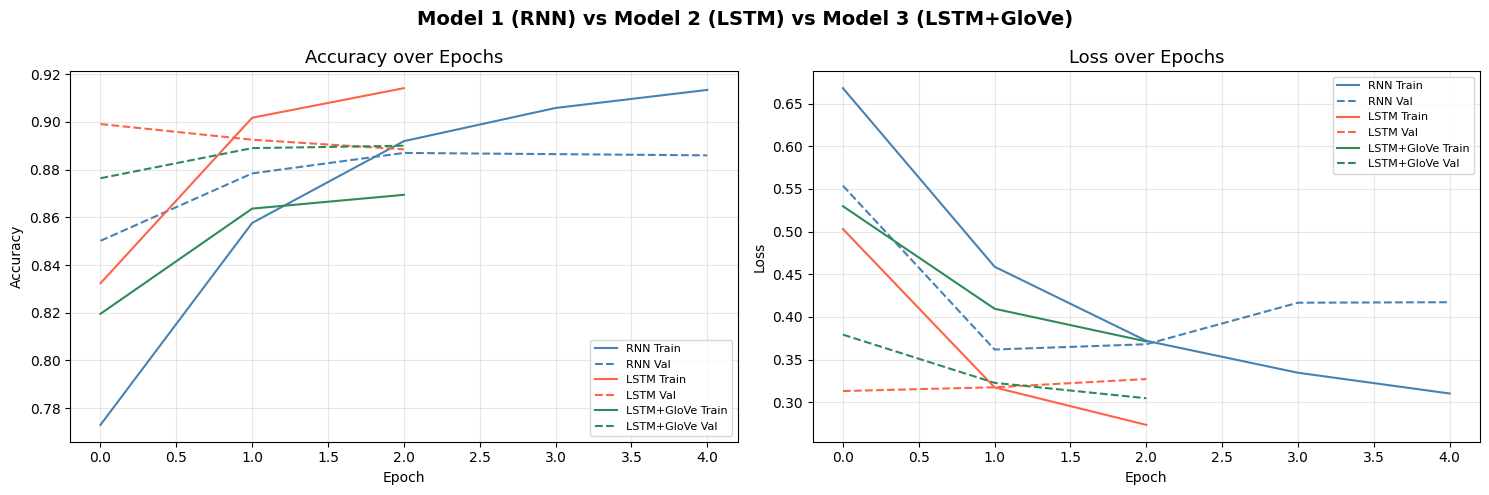

In [15]:
#Plot Training Curves
def plot_history(h1, h2, h3):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    models = [('RNN', h1, 'steelblue'),
              ('LSTM', h2, 'tomato'),
              ('LSTM+GloVe', h3, 'seagreen')]

    for name, h, color in models:
        axes[0].plot(h.history['accuracy'],
                     color=color, label=f'{name} Train')
        axes[0].plot(h.history['val_accuracy'],
                     color=color, linestyle='--', label=f'{name} Val')
        axes[1].plot(h.history['loss'],
                     color=color, label=f'{name} Train')
        axes[1].plot(h.history['val_loss'],
                     color=color, linestyle='--', label=f'{name} Val')

    axes[0].set_title('Accuracy over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Loss over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.suptitle('Model 1 (RNN) vs Model 2 (LSTM) vs Model 3 (LSTM+GloVe)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history1, history2, history3)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

   Model 1 — Simple RNN
  Accuracy: 0.8682 (86.82%)

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.00      0.00      0.00       285
           neither       0.64      0.93      0.76       832
offensive language       0.94      0.92      0.93      3836

          accuracy                           0.87      4953
         macro avg       0.53      0.62      0.56      4953
      weighted avg       0.84      0.87      0.85      4953



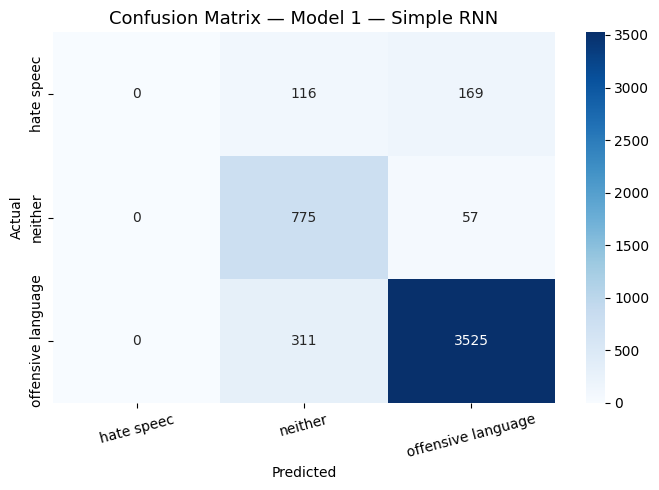

155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

   Model 2 — LSTM
  Accuracy: 0.8924 (89.24%)

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.00      0.00      0.00       285
           neither       0.77      0.89      0.82       832
offensive language       0.92      0.96      0.94      3836

          accuracy                           0.89      4953
         macro avg       0.56      0.62      0.59      4953
      weighted avg       0.84      0.89      0.87      4953



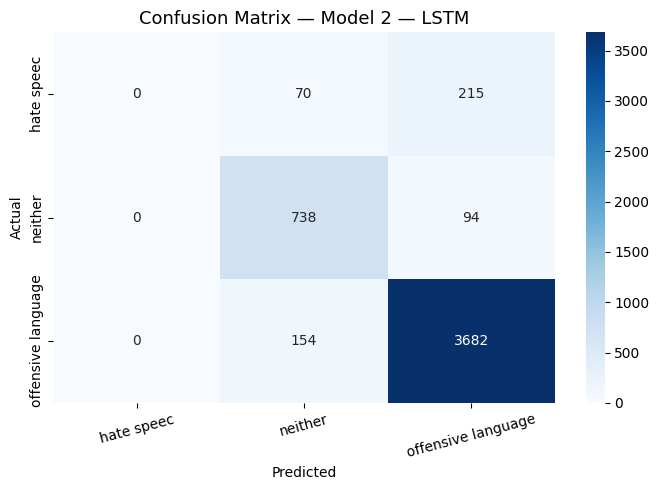

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step

   Model 3 — LSTM + GloVe
  Accuracy: 0.8791 (87.91%)

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.00      0.00      0.00       285
           neither       0.78      0.78      0.78       832
offensive language       0.90      0.97      0.93      3836

          accuracy                           0.88      4953
         macro avg       0.56      0.58      0.57      4953
      weighted avg       0.83      0.88      0.85      4953



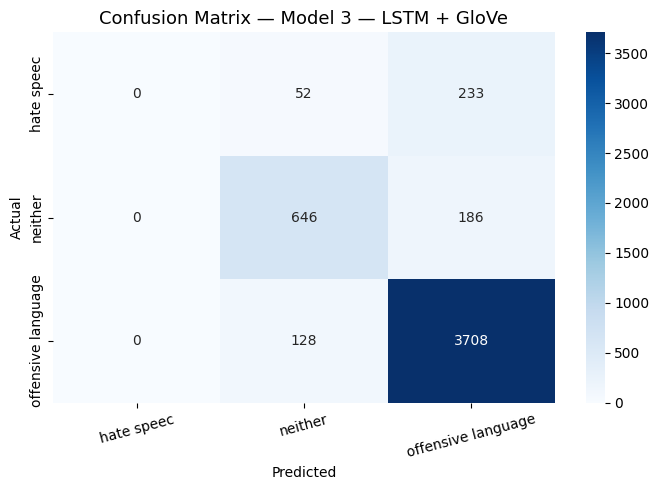


   FINAL MODEL COMPARISON SUMMARY
  Model                       Accuracy
  -------------------------------------
  Simple RNN                    86.82%
  LSTM                          89.24%
  LSTM + GloVe                  87.91%


In [16]:
#Evaluate All Models
def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_cat,  axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*55}")
    print(f"   {name}")
    print(f"{'='*55}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
          target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    return y_pred, y_true, acc

pred1, true1, acc1 = evaluate_model(model1, 'Model 1 — Simple RNN')
pred2, true2, acc2 = evaluate_model(model2, 'Model 2 — LSTM')
pred3, true3, acc3 = evaluate_model(model3, 'Model 3 — LSTM + GloVe')

# Summary Table
print("\n" + "="*45)
print("   FINAL MODEL COMPARISON SUMMARY")
print("="*45)
print(f"  {'Model':<25} {'Accuracy':>10}")
print(f"  {'-'*37}")
print(f"  {'Simple RNN':<25} {acc1*100:>9.2f}%")
print(f"  {'LSTM':<25} {acc2*100:>9.2f}%")
print(f"  {'LSTM + GloVe':<25} {acc3*100:>9.2f}%")
print("="*45)

In [17]:
# Error Analysis
print(" ERROR ANALYSIS — Model 3 (LSTM + GloVe)\n")

errors_idx = np.where(pred3 != true3)[0]
print(f"Total misclassified: {len(errors_idx)} / {len(true3)}")

print("\n── 3 Sample Misclassifications ──\n")
for i, idx in enumerate(errors_idx[:3]):
    print(f"Example {i+1}:")
    print(f"  Tweet (original) : {X_test[idx]}")
    print(f"  True Label       : {le.classes_[true3[idx]]}")
    print(f"  Predicted Label  : {le.classes_[pred3[idx]]}")
    print(f"  Possible Reason  : Ambiguous language or sarcasm\n")

 ERROR ANALYSIS — Model 3 (LSTM + GloVe)

Total misclassified: 599 / 4953

── 3 Sample Misclassifications ──

Example 1:
  Tweet (original) : hungry ferkin nip
  True Label       : offensive language
  Predicted Label  : neither
  Possible Reason  : Ambiguous language or sarcasm

Example 2:
  Tweet (original) : gansitos atg beaner candy
  True Label       : offensive language
  Predicted Label  : neither
  Possible Reason  : Ambiguous language or sarcasm

Example 3:
  Tweet (original) : best friend love justin beiber fag
  True Label       : hate speec
  Predicted Label  : offensive language
  Possible Reason  : Ambiguous language or sarcasm



In [20]:
#Real-Time GUI (Gradio)
!pip install gradio -q
import gradio as gr

def predict_hate_speech(tweet):
    if not tweet.strip():
        return " Please enter a tweet."
    cleaned = clean_text(tweet)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len,
                            padding='post', truncating='post')
    prob    = model3.predict(padded)[0]
    pred_class  = np.argmax(prob)
    label       = le.classes_[pred_class]
    confidence  = float(prob[pred_class])

    emoji = {"hate speech": "", "offensive language": "", "neither": ""}
    return (f"{emoji.get(label,'')} **{label.upper()}**\n\n"
            f"Confidence: {confidence:.2%}\n\n"
            f"Probabilities:\n"
            f"  Hate Speech        : {prob[0]:.2%}\n"
            f"  Neither            : {prob[1]:.2%}\n"
            f"  Offensive Language : {prob[2]:.2%}")

demo = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(lines=3,
                      placeholder="Type a tweet here...",
                      label="Input Tweet"),
    outputs=gr.Markdown(label="Prediction"),
    title=" Hate Speech Detector",
    description="Detects whether a tweet is Hate Speech, Offensive Language, or Neither.\nModel: LSTM + GloVe Twitter Embeddings"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2375868b900386ef46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#Save Everything to Drive
save_dir = '/content/drive/MyDrive/AIML/DATA/4.Description Hate Speech Dataset.txt'
os.makedirs(save_dir, exist_ok=True)

model1.save(save_dir + 'model1_rnn.h5')
model2.save(save_dir + 'model2_lstm.h5')
model3.save(save_dir + 'model3_lstm_glove.h5')

with open(save_dir + 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open(save_dir + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(" All models saved to Google Drive!")
print(f"    {save_dir}")

 All models saved to Google Drive!
    /content/drive/MyDrive/AI and Machine learning/HateSpeech_Models/
